In [1]:
!nvidia-smi

Mon Jun 22 02:25:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/huongng389/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 51 (delta 14), reused 7 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 52.76 KiB | 7.54 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [3]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [4]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 17.7 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: req

In [5]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

In [6]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [7]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  15.0M      0  0:00:17  0:00:17 --:--:-- 17.1M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  18.6M      0  0:00:04  0:00:04 --:--:-- 18.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0   133k      0 --:--:-- --:--:-- --:--:--  133k


In [8]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [9]:
import shutil

In [10]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [11]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [12]:
batch_size = 15

trainset = torchvision.datasets.ImageFolder(root='./data/GTSRB/Final_Training/Images',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

testset = torchvision.datasets.ImageFolder(root='./data/GTSRB/test',
                                                transform=transforms.Compose([
                                                          transforms.Resize((224,224)),
                                                          transforms.ToTensor(),
                                                          ]),
                                               )

train_loader = torch.utils.data.DataLoader(dataset=trainset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

test_loader = torch.utils.data.DataLoader(dataset=testset,
                                         batch_size=batch_size,
                                         shuffle=True
                                         )

In [13]:
batch = next(iter(train_loader))
train_data = batch[0]

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

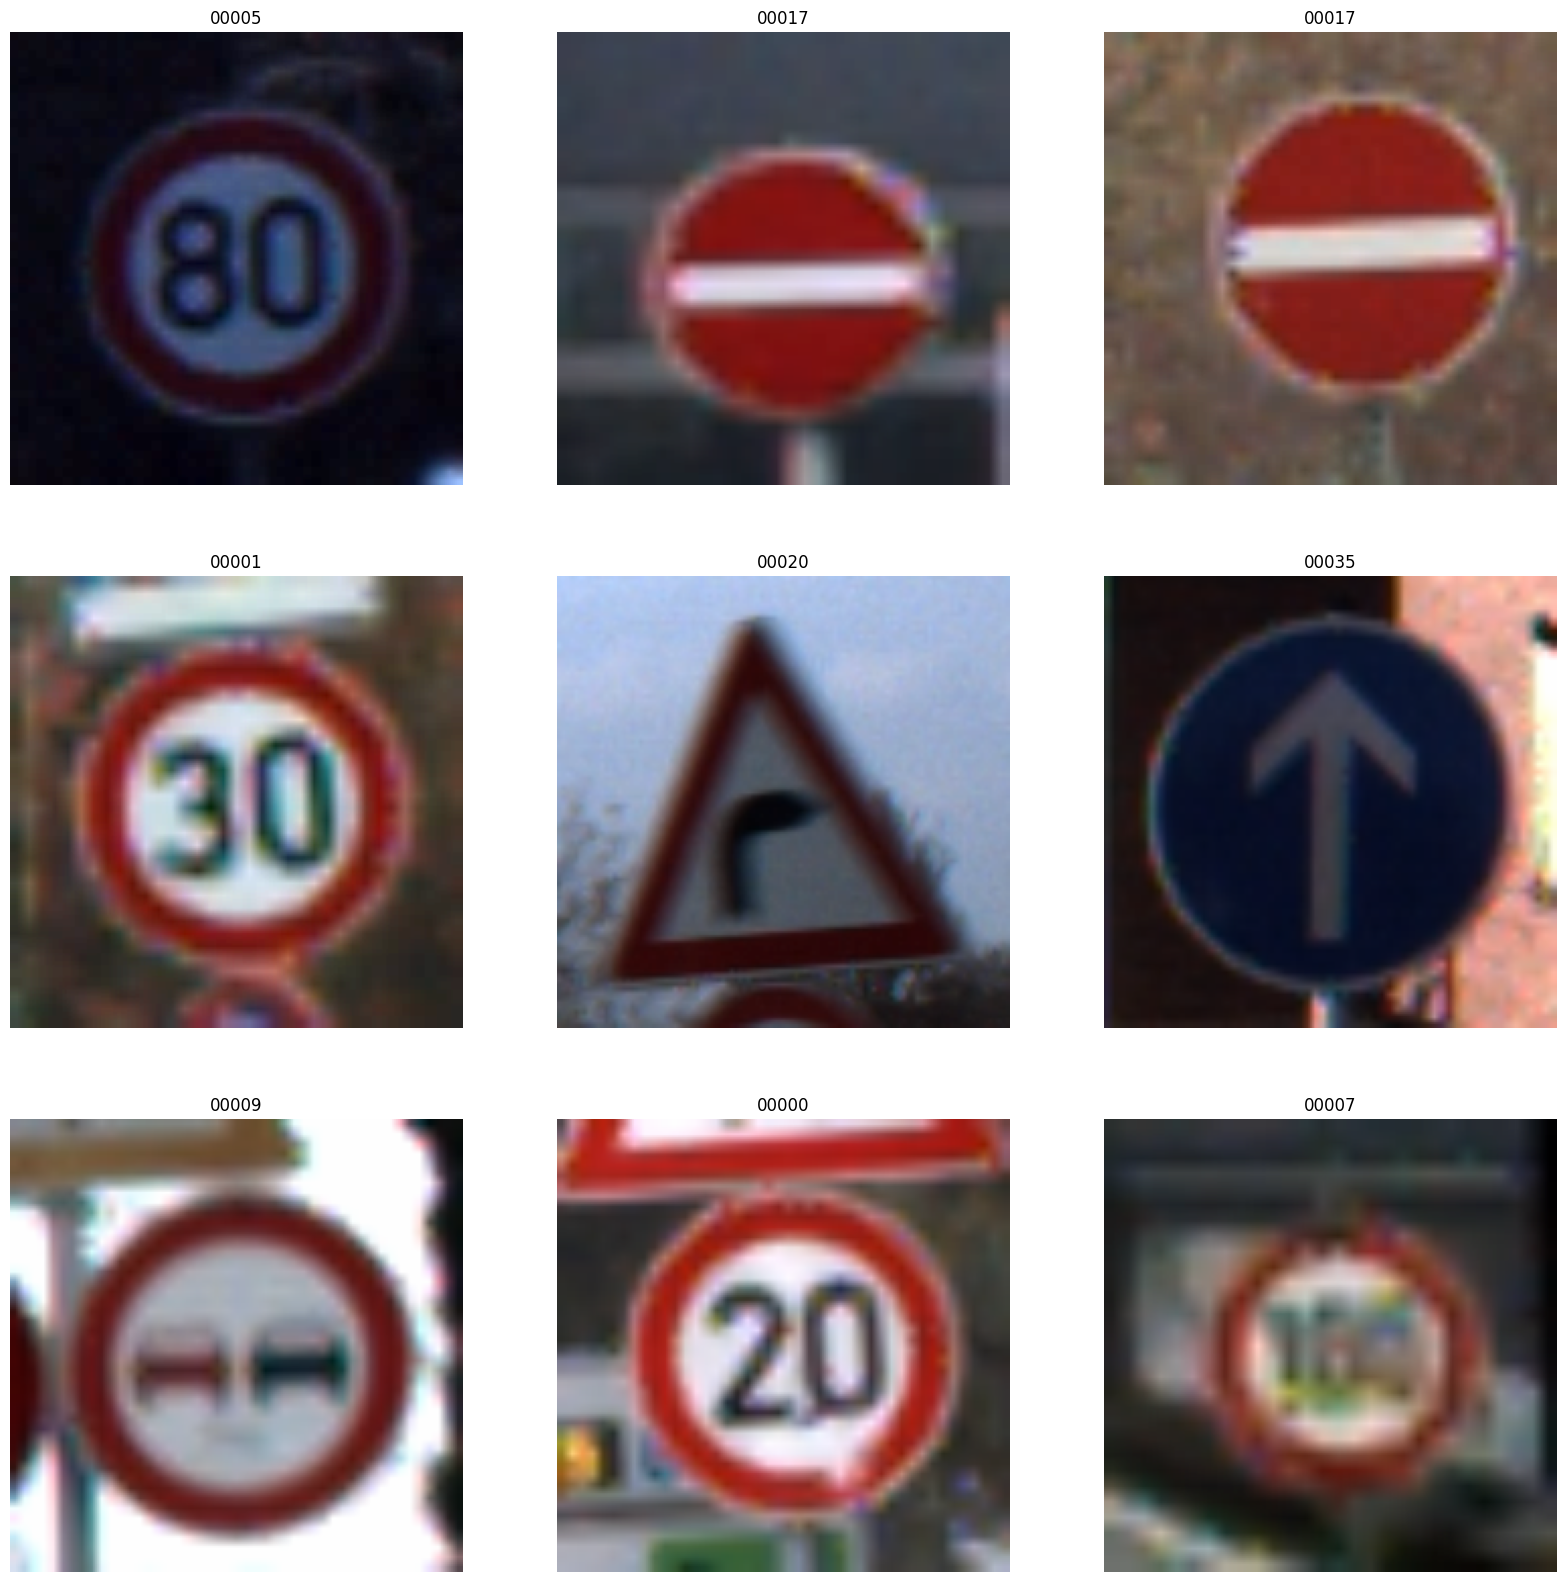

In [15]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [16]:
pip install timm

In [17]:
pip install einops

In [18]:
from LNL import LNL_Ti as small

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [19]:
model = small(pretrained=False)

In [20]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [21]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [22]:
model = model.cuda()

## Train Locality-iN-Locality

In [23]:
num_epochs = 5

In [24]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [25]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda()
        Y = batch_labels.cuda()

        pre = model(X)
        cost = loss(pre, Y)

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/5], lter [200/2613], Loss: 3.394965
Epoch [1/5], lter [400/2613], Loss: 2.709785
Epoch [1/5], lter [600/2613], Loss: 2.080434
Epoch [1/5], lter [800/2613], Loss: 1.805735
Epoch [1/5], lter [1000/2613], Loss: 0.891117
Epoch [1/5], lter [1200/2613], Loss: 0.306633
Epoch [1/5], lter [1400/2613], Loss: 0.196164
Epoch [1/5], lter [1600/2613], Loss: 0.472821
Epoch [1/5], lter [1800/2613], Loss: 0.170975
Epoch [1/5], lter [2000/2613], Loss: 0.034601
Epoch [1/5], lter [2200/2613], Loss: 0.187773
Epoch [1/5], lter [2400/2613], Loss: 0.112212
Epoch [1/5], lter [2600/2613], Loss: 0.012069
Epoch [2/5], lter [200/2613], Loss: 0.005368
Epoch [2/5], lter [400/2613], Loss: 0.019029
Epoch [2/5], lter [600/2613], Loss: 0.005722
Epoch [2/5], lter [800/2613], Loss: 0.005009
Epoch [2/5], lter [1000/2613], Loss: 0.003703
Epoch [2/5], lter [1200/2613], Loss: 0.031584
Epoch [2/5], lter [1400/2613], Loss: 0.001253
Epoch [2/5], lter [1600/2613], Loss: 0.001081
Epoch [2/5], lter [1800/2613], Loss: 0.001

## Test

In [26]:
model.eval()
correct = 0
total = 0

for images, labels in test_loader:

    images = images.cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Standard accuracy: 97.18 %


## FGSM attack

In [27]:
model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 64.58 %


## PGD attack

In [28]:
model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:

    images = atk(images, labels).cuda()
    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels.cuda()).sum()

print('Robust accuracy: %.2f %%' % (100 * float(correct) / total))

Robust accuracy: 51.51 %


## train LNL-MoEx

In [29]:
from LNL_MoEx import LNL_MoEx_Ti as small
model = small(pretrained=False)
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

/content/Locality-iN-Locality/models/tnt_moex.py:312: UserWarning: Overwriting tnt_t_patch16_224 in registry with models.tnt_moex.tnt_t_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/Locality-iN-Locality/models/tnt_moex.py:323: UserWarning: Overwriting tnt_s_patch16_224 in registry with models.tnt_moex.tnt_s_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/Locality-iN-Locality/models/tnt_moex.py:334: UserWarning: Overwriting tnt_b_patch16_224 in registry with models.tnt_moex.tnt_b_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model


In [30]:
model = model.cuda()

In [31]:
import time
# time.clock_gettime()

In [32]:
num_epochs = 5
moex_lam = .9
moex_prob = .7

In [33]:
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.007, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [34]:
for epoch in range(num_epochs):

    total_batch = len(trainset) // batch_size

    for i, (input, target) in enumerate(train_loader):
        input = input.cuda()
        target = target.cuda()

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]
            output = model(input, swap_index=swap_index, moex_norm='pono', moex_epsilon=1e-5,
                           moex_layer='stem', moex_positive_only=False)
            lam = moex_lam
            cost = loss(output, target_a) * lam + loss(output, target_b) * (1. - lam)
        else:
            # compute output
            output = model(input)
            # if args.prof >= 0: torch.cuda.nvtx.range_pop()
            cost = loss(output, target)

        # compute gradient and do SGD step

        optimizer.zero_grad()
        cost.backward()
        optimizer.step()

        if (i+1) % 200 == 0:
            print('Epoch [%d/%d], lter [%d/%d], Loss: %.6f'
                 %(epoch+1, num_epochs, i+1, total_batch, cost.item()))

Epoch [1/5], lter [200/2613], Loss: 3.458183
Epoch [1/5], lter [400/2613], Loss: 2.765113
Epoch [1/5], lter [600/2613], Loss: 2.485440
Epoch [1/5], lter [800/2613], Loss: 1.632661
Epoch [1/5], lter [1000/2613], Loss: 1.121562
Epoch [1/5], lter [1200/2613], Loss: 1.718946
Epoch [1/5], lter [1400/2613], Loss: 0.952449
Epoch [1/5], lter [1600/2613], Loss: 0.973573
Epoch [1/5], lter [1800/2613], Loss: 0.857376
Epoch [1/5], lter [2000/2613], Loss: 0.121404
Epoch [1/5], lter [2200/2613], Loss: 0.659427
Epoch [1/5], lter [2400/2613], Loss: 0.684524
Epoch [1/5], lter [2600/2613], Loss: 0.119231
Epoch [2/5], lter [200/2613], Loss: 0.036844
Epoch [2/5], lter [400/2613], Loss: 0.686146
Epoch [2/5], lter [600/2613], Loss: 0.660493
Epoch [2/5], lter [800/2613], Loss: 0.697420
Epoch [2/5], lter [1000/2613], Loss: 0.614667
Epoch [2/5], lter [1200/2613], Loss: 0.805180
Epoch [2/5], lter [1400/2613], Loss: 0.006134
Epoch [2/5], lter [1600/2613], Loss: 0.663830
Epoch [2/5], lter [1800/2613], Loss: 0.711

## Number of Parameters

In [35]:
pip install ptflops

In [36]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

  Cloning https://github.com/sovrasov/flops-counter.pytorch.git to /tmp/pip-req-build-qrv570ns
  Running command git clone --filter=blob:none --quiet https://github.com/sovrasov/flops-counter.pytorch.git /tmp/pip-req-build-qrv570ns
  Resolved https://github.com/sovrasov/flops-counter.pytorch.git to commit d612c7547445841a325fd2a1ff2ab27583f01bae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptflops: filename=ptflops-0.7.6-py3-none-any.whl size=19501 sha256=f1852d2113185c7313ddd74b74cd634b5ffc2a75e76ce63a5ac88f28f8acfbbd
  Stored in directory: /tmp/pip-ephem-wheel-cache-czp__awd/wheels/c3/60/94/c0a4677f6c1ff199ef7a6717fa47797ea51309624895931fe9
Successfully built ptflops
  Attempting uninstall: ptflops
    Found existing installation: ptflops 0.7.5
    Uninstalling ptflops-0.7.5:
      Successfully uninstalled ptflops-0.7.5


In [37]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))


LocalViT_TNT(
  6.04 M, 99.371% Params, 1.24 GMac, 99.710% MACs, 
  (pixel_embed): PixelEmbed(
    1.78 k, 0.029% Params, 5.57 MMac, 0.446% MACs, 
    (proj): Conv2d(1.78 k, 0.029% Params, 5.57 MMac, 0.446% MACs, 3, 12, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    (unfold): Unfold(0, 0.000% Params, 0.0 Mac, 0.000% MACs, kernel_size=4, dilation=1, padding=0, stride=4)
  )
  (norm1_proj): LayerNorm(384, 0.006% Params, 37.63 KMac, 0.003% MACs, (192,), eps=1e-05, elementwise_affine=True)
  (proj): Linear(37.06 k, 0.610% Params, 7.26 MMac, 0.582% MACs, in_features=192, out_features=192, bias=True)
  (norm2_proj): LayerNorm(384, 0.006% Params, 37.63 KMac, 0.003% MACs, (192,), eps=1e-05, elementwise_affine=True)
  (pos_drop): Dropout(0, 0.000% Params, 0.0 Mac, 0.000% MACs, p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      499.16 k, 8.215% Params, 102.59 MMac, 8.223% MACs, 
      (norm_in): LayerNorm(24, 0.000% Params, 37.63 KMac, 0.003% MACs, (12,), eps=1e-